<figure style="text-align: center;">
  <img src="_static/intro/title_page.png" style="display: block; margin: 0 auto; width: 100%;">
</figure>

### Ensemble Kalman Filtering (EnKF)

Michael J. Pyrcz, Professor, The University of Texas at Austin 

[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

Chapter of e-book "Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy". 

```{admonition} Cite this e-Book as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy* [e-book]. Zenodo. doi:10.5281/zenodo.15169133 [![DOI](https://zenodo.org/badge/838927017.svg)](https://doi.org/10.5281/zenodo.15169132)  
```

The workflows in this book and more are available here:

```{admonition} Cite the GeostatsPyDemos GitHub Repository as:
:class: remove-from-content-only

Pyrcz, M.J., 2024, *GeostatsPyDemos: GeostatsPy Python Package for Spatial Data Analytics and Geostatistics Demonstration Workflows Repository* (0.0.1) [Software]. Zenodo. doi:10.5281/zenodo.12667036. GitHub Repository: https://github.com/GeostatsGuy/GeostatsPyDemos [![DOI](https://zenodo.org/badge/777871341.svg)](https://doi.org/10.5281/zenodo.12667035)



```

By Michael J. Pyrcz <br />
&copy; Copyright 2026.

The Ensemble Kalman Filter (EnKF) is a sequential data assimilation method that,

* uses an ensemble of realizations to represent uncertainty

* updates model states or parameters by combining model predictions with noisy observations through covariance-based corrections

The method was introduced by Geir Evensen (1994) as a computationally efficient Monte Carlo implementation of the Kalman filter for large nonlinear systems.

EnKF and related data assimilation methods are widely applied in subsurface modeling to integrate model responses with model parameters, a process also known as inverse modeling. Examples include,

* **production history matching** – petroleum reservoir modeling in petroleum geology and petroleum engineering  

* **model calibration** – groundwater flow and catchment modeling in hydrology  

* **inverse analysis (back-analysis)** – structural stability and failure analysis in rock mechanics

Let's first introduce the workflow with the detailed workflow and math. Then I will walk through a very, very simple toy problem for petroleum history matching with codes so we can play with this method.

#### General Ensemble Kalman Filter (EnKF) Workflow

Let's start by explaining the The Ensemble Kalman Filter (EnKF) is a sequential data assimilation method that combines,

* uncertain model predictions

* noisy observations

to improve estimates of unknown system states or parameters.

The EnKF represents uncertainty using an ensemble of realizations of the unknown model parameters and updates this ensemble sequentially in time as new observations become available.

Here are the general EnKF steps,

1. Define the unknown model parameter(s), also known as the state variables  

2. Generate an initial ensemble, consisting of realizations of the unknown model parameters  

3. Forecast the system response by applying the forward (physics) model to each ensemble member  

4. Collect observations and compute the misfit between the observations and the forecasted system response  

5. Compute ensemble statistics (means and covariances)  

6. Compute the Kalman gain  

7. Update the ensemble using the observations  

8. Repeat sequentially through time, returning to Step 3 for the next time step  

We see the general EnKF loop,

$$
\text{Forecast} \rightarrow \text{Observe} \rightarrow \text{Update} \rightarrow \text{Repeat at Next Time Step}
$$

Next, we will walk through each step and define all relevant terms in detail.


#### Step 1. Define the Unknown State Variables or Parameters

The Ensemble Kalman Filter (EnKF) estimates a vector of unknown model parameters,

$$
\mathbf{x}
$$

where $\mathbf{x}$ is the **state vector** (or model parameter vector).

**Spatial representation of the state**

In many subsurface applications, the state variables are defined over a spatial model grid in 1D, 2D, or 3D. The spatial location of each grid cell is represented by a coordinate vector,

$$
\mathbf{u}_\alpha
$$

where $\alpha$ indexes location within the domain of interest.

The spatially distributed state can then be written as,

$$
\mathbf{x}(\mathbf{u}_\alpha), \quad \forall \quad \alpha \in \text{AOI}
$$

where AOI is the area (or volume) of interest, and $\mathbf{x}(\mathbf{u}_\alpha)$ is the state value at location $\mathbf{u}_\alpha$

* while spatial location is implied, for concise notation I omit this location vector below.

**Prior uncertainty and ensemble interpretation**

The initial ensemble represents our prior uncertainty about the system state before any data assimilation,

* each ensemble member is a realization of the full state,

$$
\mathbf{x}^{(\ell)}, \quad \ell = 1,\ldots,N_e
$$

**State space definition**

The **state space** is the mathematical space containing all possible values of the system state vector. If the state vector is,

$$
\mathbf{x} =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
\in \mathbb{R}^n
$$

then the **state space** is,

$$
\mathbb{R}^n
$$

**Examples of state variables**

Typical model state variables in subsurface and geoscience applications include,

- permeability  
- pressure  
- porosity  
- temperature  
- velocity  
- saturation
  

#### Step 2. Generate an Initial Ensemble

Uncertainty is represented using an ensemble of realizations for the state variable(s), $\mathbf{x}$,

$$
\mathbf{x}^{(1)},
\mathbf{x}^{(2)},
\ldots,
\mathbf{x}^{(N_e)}
$$

where $N_e$ is the number of ensemble members, and $\mathbf{x}^{(\ell)}$ is the $\ell$-th ensemble member, with $\ell = 1,\ldots,N_e$

The ensemble is sampled from a prior distribution,

$$
\mathbf{x}^{(\ell)} \sim f_{\text{prior}}(\mathbf{x})
$$

where $f_{\text{prior}}(\mathbf{x})$ is the prior probability density function

In this formulation, the state $\mathbf{x}$ represents a **static unknown parameter** and therefore does **not carry a time index**,

$$
\mathbf{x}^{(\ell)} \neq \mathbf{x}_t^{(\ell)}
$$

Time dependence will enter later through the **observations** and their model-predicted counterparts,

$$
\mathbf{y}^{obs}_t,\quad \hat{\mathbf{y}}^{(\ell)}_t = g(\mathbf{x}^{(\ell)})
$$

#### Step 3. Forecast the System Response

Each ensemble member is propagated through a forward model,

$$
\hat{\mathbf{y}}^{(\ell)}
=
g\left(
\mathbf{x}^{(\ell)}
\right)
$$

where $g(\cdot)$ is the forward (observation) model, $\mathbf{x}^{(\ell)}$ is the $\ell$-th ensemble realization of the state, and $\hat{\mathbf{y}}^{(\ell)}$ is the model-predicted observation for ensemble member $\ell$

The collection,

$$
\left\{
\hat{\mathbf{y}}^{(1)},
\hat{\mathbf{y}}^{(2)},
\ldots,
\hat{\mathbf{y}}^{(N_e)}
\right\}
$$

forms the **ensemble of predicted observations**, generated by mapping the ensemble of model parameters $\mathbf{x}$ into observation space through the forward model $g(\cdot)$.

#### Step 4. Collect Observations

Measurements are collected from the real system at discrete times $t$,

$$
\mathbf{y}^{obs}_t
$$

where $\mathbf{y}^{obs}_t$ is the observation vector at times $t$, $t = 1,2,\dots,N_t$ and observations at these times are noisy, containing measurement uncertainty,

$$
\mathbf{y}^{obs}_t
=
g(\mathbf{x}_{true,t})
+
\boldsymbol{\epsilon}_t
$$

where $\mathbf{x}_{true}$ is the true (unavailable) system state, and $\boldsymbol{\epsilon}$ is the observation error at time step, $t$

Observation error is often assumed Gaussian distributed,

$$
\boldsymbol{\epsilon}_t
\sim
\mathcal{N}(\mathbf{0},\mathbf{R})
$$

where $\mathbf{R}$ is the observation error covariance matrix


#### Step 5. Compute Ensemble Statistics

The Ensemble Kalman Filter (EnKF) computes required statistics directly from the ensemble realizations.

##### Ensemble mean (state space)

The ensemble mean of the state (unknown parameter) is,

$$
\bar{\mathbf{x}}
=
\frac{1}{N_e}
\sum_{\ell=1}^{N_e}
\mathbf{x}^{(\ell)}
$$

where $\mathbf{x}^{(\ell)}$ is the state (or parameter) of ensemble member $\ell$, $N_e$ = number of ensemble members, and $\bar{\mathbf{x}}$ = ensemble mean state

##### Ensemble mean (observation space)

The ensemble mean of the predicted observations is,

$$
\bar{\hat{\mathbf{y}}}_t
=
\frac{1}{N_e}
\sum_{\ell=1}^{N_e}
\hat{\mathbf{y}}_t^{(\ell)}
$$

where $\hat{\mathbf{y}}_t^{(\ell)} = g(\mathbf{x}^{(\ell)})$ is the model-predicted observation for ensemble member $\ell$ at time $t$, and $\bar{\hat{\mathbf{y}}}_t$ is the ensemble mean of predicted observations at time $t$

##### Cross-covariance (state–observation)

The cross-covariance between the state ensemble and predicted observation ensemble at time $t$ is,

$$
\mathbf{C}_{x\hat{y},t}
=
\frac{1}{N_e-1}
\sum_{\ell=1}^{N_e}
\left(
\mathbf{x}^{(\ell)} - \bar{\mathbf{x}}
\right)
\left(
\hat{\mathbf{y}}_t^{(\ell)} - \bar{\hat{\mathbf{y}}}_t
\right)^T
$$

where $\mathbf{C}_{x\hat{y},t}$ is the cross-covariance between state and predicted observations at time $t$, $\mathbf{x}^{(\ell)}$ is the ensemble state, $\hat{\mathbf{y}}_t^{(\ell)}$ is the model-predicted observation at time $t$, and $(\cdot)^T$ is the transpose operator

##### Interpretation

The matrix $\mathbf{C}_{x\hat{y},t}$ measures how variations in the model parameters ($\mathbf{x}$) are correlated with variations in the predicted observations ($\hat{\mathbf{y}}_t$).

* This relationship is computed **at each observation time $t$**

* It determines how strongly observational information at time $t$ updates the state in the Kalman gain step

Importantly, the **state ensemble $\mathbf{x}^{(\ell)}$ does not carry a time index**, since it represents a static unknown parameter. Only the forward-mapped predictions $\hat{\mathbf{y}}_t^{(\ell)}$ evolve with time.


#### Step 6. Compute the Kalman Gain

The Kalman gain determines how strongly observations influence the update at time $t$:

$$
\mathbf{K}_t
=
\mathbf{C}_{x\hat{y},t}
\left(
\mathbf{C}_{\hat{y}\hat{y},t}
+
\mathbf{R}_t
\right)^{-1}
$$

where $\mathbf{K}_t$ is the Kalman gain matrix at time $t$, $\mathbf{C}_{x\hat{y},t}$ is the cross-covariance between the state ensemble and predicted observations at time $t$, $\mathbf{C}_{\hat{y}\hat{y},t}$ is the covariance of the predicted observations at time $t$, and $\mathbf{R}_t$ is the observation error covariance at time $t$.


#### Step 7. Update the Ensemble

Each ensemble member is updated using the innovation (the difference between observations and predictions) at time $t$:

$$
\mathbf{x}_{new}^{(\ell)}
=
\mathbf{x}_{old}^{(\ell)}
+
\mathbf{K}_t
\left(
\mathbf{y}_t^{obs,(\ell)}
-
\hat{\mathbf{y}}_t^{(\ell)}
\right)
$$

where $\mathbf{x}_{old}^{(\ell)}$ is the forecasted ensemble member before assimilation at time $t$, $\mathbf{x}_{new}^{(\ell)}$ is the updated (analysis) ensemble member at time $t$, $\mathbf{y}_t^{obs,(\ell)}$ is the perturbed observation at time $t$, and $\hat{\mathbf{y}}_t^{(\ell)}$ is the model-predicted observation at time $t$.


#### Step 8. Repeat Sequentially Through Time

The EnKF assimilates observations sequentially (forward) through time,

$$
t = 1,2,\ldots,N_t
$$

where $t$ are time steps and $N_t$ is the total number of time steps. At each time step, $t$, we apply these steps once.


```{admonition} Ensemble Kalman Filter (EnKF) Workflow
:class: remove-from-content-only

The Ensemble Kalman Filter (EnKF) operates as a sequential data assimilation cycle that integrates model predictions with observed data to update uncertain model parameters.

The general workflow is:

**I. Forecast the system**  
Propagate each ensemble member through the forward model to generate predicted observations.

**II. Compare predictions with observations**  
Compute the innovation (misfit) between observed data and ensemble-predicted observations.

**III. Compute ensemble statistics**  
Estimate means and covariance relationships from the ensemble in state and observation space.

**IV. Compute the Kalman gain**  
Quantify how strongly observations should influence updates using covariance structure and observation uncertainty.

**V. Update the ensemble**  
Correct each ensemble member using the Kalman gain and the observation misfit.

This process is repeated sequentially in time as new observations become available, continually refining the estimate of the unknown model parameters.
```

Note, this workflow assumes that errors are not large and are Gaussian distributed. 

* very large updates or errors that invalidate the Gaussian assumption may break the math and degrade model performance

For these cases consider the application of Iterative Ensemble Kalman Filter (IEnKF) or Ensemble Randomized Maximum Likelihood (EnRML) methods

As more observations are assimilated,

* uncertainty decreases

* predictions improve

* the ensemble converges toward the true system

#### General EnKF Workflow Summary

The salient aspects of Ensemble Kalman Filter (EnKF) includes,

* represents uncertainty with ensembles

* propagates uncertainty through a forward model

* compares predictions with observations

* updates realizations using covariance relationships

* sequentially improves estimates as new data arrive

#### Physics Model

For our demonstration we have a simple, single phase hydrocarbon production problem. For this problem we have a physics-based deterministic model for the forward modeling based on conservation of mass and momentum. 

The mathematical foundation for multiphase subsurface flow rests on a set of coupled, nonlinear partial differential equations (PDEs).

##### Continuity Equation (Conservation of Mass)

$$
\nabla \cdot (\rho_p \mathbf{v}_p) + q_p
=
\frac{\partial (\phi \rho_p S_p)}{\partial t}
$$

##### Darcy's Law (Conservation of Momentum)

$$
\mathbf{v}_p
=
-\frac{k k_{rp}}{\mu_p}
\left(
\nabla p_p - \rho_p g \nabla Z
\right)
$$

where,

- $p_p$ : pressure of phase $p$
- $S_p$ : saturation of phase $p$ (e.g., oil, gas, water)
- $\phi$ : porosity of the rock
- $\mathbf{v}_p$ : Darcy velocity
- $k$ : absolute permeability
- $k_{rp}$ : relative permeability
- $\mu_p$ : fluid viscosity
- $\rho_p$ : fluid density
- $q_p$ : source/sink term representing injection or production flow rates
- $g$ : gravitational acceleration
- $Z$ : elevation/depth coordinate

#### Ensemble Kalman Filtering (EnKF) for Estimating Permeability from Pressure Observations

In this demonstration, we use the Ensemble Kalman Filter (EnKF) to estimate a single unknown permeability value from noisy pressure observations collected through time.

The workflow includes,

1. Define the unknown model parameter
2. Generate an ensemble of permeability realizations
3. Forecast pressure responses for each ensemble member
4. Generate noisy observations
5. Compute ensemble statistics
6. Compute the Kalman gain
7. Update the permeability ensemble
8. Repeat sequentially through time

##### 1. Define the unknown model parameter

We estimate a single unknown permeability value:

$$
k
$$

##### 2. Generate an ensemble of permeability realizations

Create an initial ensemble representing uncertainty in permeability:

$$
k^{(\ell)}, \quad \ell = 1,\ldots,N_e
$$

##### 3. Forecast pressure responses for each ensemble member

Apply Darcy’s law to map permeability to pressure,

$$
\hat{P}_t^{(\ell)} = \frac{q_t}{k^{(\ell)}}
$$

##### 4. Generate noisy observations

Pressure observations are collected over time with measurement noise,

$$
P_t^{obs} = \frac{q_t}{k_{true}} + \epsilon_t
$$

##### 5. Compute ensemble statistics

Compute statistics from the ensemble of parameters and predicted pressures,

$$
\bar{k}, \quad \bar{\hat{P}}_t
$$

where $\bar{k}$ is the ensemble mean permeability and $\bar{\hat{P}}_t$ is the ensemble mean predicted pressure at time $t$.

The cross-covariance is then computed as,

$$
\mathbf{C}_{k\hat{P},t}
$$

where $\mathbf{C}_{k\hat{P},t}$ is the covariance between the permeability ensemble and the predicted pressure ensemble at time $t$, quantifying how variations in permeability are linearly related to variations in predicted pressure.

This covariance is the key statistical link between the model parameters and the observations, and it directly controls the Kalman gain in the next step.

##### 6. Compute the Kalman gain

Compute the Kalman gain as,

$$
K_t =
\frac{\mathbf{C}_{k\hat{P},t}}
{\sigma^2_{\hat{P}_t} + R_t}
$$

where $K_t$ is the Kalman gain at time $t$, $\mathbf{C}_{k\hat{P},t}$ is the covariance between permeability and predicted pressure at time $t$, $\sigma^2_{\hat{P}_t}$ is the variance of the predicted pressure ensemble at time $t$, and $R_t$ is the observation error variance at time $t$.

- $\mathbf{C}_{k\hat{P},t}$ quantifies how variations in permeability explain variations in predicted pressure  
- $\sigma^2_{\hat{P}_t}$ represents the spread (uncertainty) of the predicted pressure ensemble  
- $R_t$ represents measurement noise in the observed pressure data  

This ratio determines how strongly the observation at time $t$ will adjust the permeability ensemble.

##### 7. Update the permeability ensemble

Each ensemble member is updated using the observation misfit,

$$
k^{(\ell)} \leftarrow k^{(\ell)} + K_t \left(P_t^{obs,(\ell)} - \hat{P}_t^{(\ell)}\right)
$$

#### 8. Repeat sequentially through time

Return to Step 3 as new pressure observations become available, continuously refining the permeability estimate.

#### Darcy’s Law (1-cell form used in this EnKF example)

In this simplified 1-cell system, we relate flow, pressure, and permeability using Darcy’s law,

$$
q_t = k \, A \, \frac{\Delta P_t}{L}
$$

Rearranged to express pressure (as used in the EnKF forward model),

$$
P_t = \frac{q_t L}{k A}
$$

For the single-cell demonstration, constants are often lumped into a single coefficient,

$$
P_t = \frac{q_t}{k}
$$

so the forward model becomes:

$$
\hat{P}_t^{(\ell)} = \frac{q_t}{k^{(\ell)}}
$$

where,
- $q_t$ = flow rate at time $t$
- $P_t$ = pressure response at time $t$
- $\Delta P_t$ = pressure drop across the cell
- $k$ = permeability (unknown parameter)
- $A$ = cross-sectional area
- $L$ = length of the cell
- $\hat{P}_t^{(\ell)}$ = predicted pressure from ensemble member $\ell$

This reduced form of Darcy’s law assumes:

- **Single-phase flow** (no multiphase effects such as gas–oil or water–oil coupling)
- **Steady-state or quasi-steady-state flow** (no storage or transient accumulation within the cell model)
- **Linear flow regime** (Darcy flow; no turbulence or non-Darcy effects)
- **Homogeneous properties within the cell** (each ensemble member assigns a single effective permeability value)
- **Constant geometry** (area $A$ and length $L$ do not vary with time or ensemble)
- **Known forcing term** ($q_t$ is assumed measured or prescribed)

These assumptions reduce the physics to a simple monotonic mapping,

$$
k \rightarrow P_t
$$

which has several important consequences,

- The system is **strongly nonlinear in the inverse sense** (pressure depends on $1/k$)
- A single scalar parameter ($k$) is sufficient to explain all observations
- All uncertainty enters through permeability only (no model structural uncertainty)
- Each observation time provides independent information about the same static parameter
- The EnKF update progressively reduces uncertainty in $k$ as more pressure data are assimilated

This simplified Darcy formulation turns the subsurface flow problem into a clean inverse problem:

* infer a single static permeability value from repeated noisy pressure observations through a nonlinear forward mapping

#### Load the Required Libraries

The following code loads the required libraries.

In [1]:
import numpy as np                                            # ndarrays for gridded data
import matplotlib.pyplot as plt                               # plotting
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
import matplotlib.ticker as mticker
seed= 42                                                      # random number seed

If you get a package import error, you may have to first install some of these packages. This can usually be accomplished by opening up a command window on Windows and then typing 'python -m pip install [package-name]'. More assistance is available with the respective package docs. 

#### Define Functions

These are the fundamental functions required to calculate a multiple point simulation (MPS) realization, including,

* **build_synthetic_pressure_dataset** - build a simple synthetic pressure dataset given input flow rates ($\frac{m^3}{s}$), true permeability ($m^2$), and permeability error ($m^4$), fluid dynamic viscosity ($\mu$) ($Pa \cdot s$), length of flow path ($m$), cross sectional area ($m^2$) 

* **generate_initial_ensemble** - scan the training image and find data event matches, return the matches and frequencies of each facies at the matches with the option to plot the matches (red dots) over the training image

* **ensemble_mean** - vectorized code for scanning the training image for data event matches, without visualization as a speed up for simulating all previous nodes before the current visualized node

Along with convenience functions,

* **ensemble_variance** - add data to simulation model, and include any number of truth values to mimic a partially completed simulation if computational time is too long for a complete simulated realization

* **ensemble_covariance, covariance_PP, covariance_qP** - plot the simulation model with the new simulated realization added

* **compute_kalman_gain** - plot the conditional PDF for facies given the data event and training image as a pie plot

In [2]:
def build_synthetic_pressure_dataset(T, k_true, q_t, R,       # build synthetic P(t) model from q(t) and true permeability
    mu=1e-3, L=1.0,A=1.0,random_seed=None,return_true=False):
    if random_seed is not None:
        np.random.seed(random_seed)                           # set random seed for workflow repeatability       

    q_t = np.asarray(q_t)
    P_true = (q_t * mu * L) / (k_true * A)                    # Darcy law (SI consistent)

    noise = np.random.normal(0, np.sqrt(R), T)                # additive Gaussian noise (EnKF-consistent)
    P_obs = P_true + noise
    P_obs = np.clip(P_obs, 1.0, None)                         # remove non-physical values
    
    data = {"t": np.arange(T),"q_t": q_t,"P_obs": P_obs}

    if return_true:
        data["P_true"] = P_true                               # P_true to output for model checking, use P_obs 
    return data

def generate_initial_ensemble(N_e, mu_logk, sigma_logk,       # Monte Carlo simulate initial k ensemble from lognormal distribution
    random_seed=None):

    if random_seed is not None:                               # set random seed for workflow repeatability
        np.random.seed(random_seed)

    logk = np.random.normal(mu_logk, sigma_logk, N_e)         # Monte Carlo simulation n_e times
    k = np.exp(logk)
    return k

def ensemble_mean(x):                                         # calculate ensemble mean                          
    return np.mean(x)

def ensemble_variance(x):                                     # calculate ensemble variance
    Ne = len(x)
    return np.sum((x - np.mean(x))**2) / (Ne - 1)


def ensemble_covariance(x, y):                                # calculate covariance between two ensembles  
    Ne = len(x)
    return np.sum((x - np.mean(x)) * (y - np.mean(y))) / (Ne - 1)

def covariance_PP(P_hat):                                     # calculate covariance within an ensemble over locations
    return ensemble_covariance(P_hat, P_hat)

def covariance_kP(k, P_hat):                                  # calculate covariance between two ensembles 
    return ensemble_covariance(k, P_hat)

def compute_kalman_gain(C_xp, C_pp, R):                       # calculate Kalman gain (since 1 location all are scalers)
    return C_kP / (C_PP + R)                                  # for more than 1 location must switch to matrix operations

def add_grid():                                               # add grid lines to plot
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks 

def add_grid2(sub_plot):                                      # add grid lines to plot
    sub_plot.grid(True, which='major',linewidth = 1.0); sub_plot.grid(True, which='minor',linewidth = 0.2) # add y grids
    sub_plot.tick_params(which='major',length=7); sub_plot.tick_params(which='minor', length=4)
    sub_plot.xaxis.set_minor_locator(AutoMinorLocator()); sub_plot.yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks  


#### Synthetic EnKF Problem

The following code builds the simple production dataset with input flow rate, hidden true porosity (used to make the dataset but not known the the EnKF workflow).

To ensure no issues with units, I have consistently used International System of Units or Système international d'unités (SI). Here's a table of the units and typical ranges in this demonstration. 

| Quantity      | Symbol | SI Unit | Typical value (demo) | Details|
|--------------|--------|---------|------------------------|---------------|
| Permeability | k      | $m^{2}$ | $10^{-14}$ to $10^{-12}$ | ensemble variable updated over time, $k^{\ell}(t)$ |
| Flow rate    | q      | $\frac{m^3}{s}$ | $10^{-6}$ to $10^{-3}$ | variable over time, $q(t)$ |
| Pressure     | P      | $Pa$      | $10^{5}$ to $10^{7}$ | variable over time, $P(t)$ |
| Viscosity    | μ      | $Pa \cdot s$    | $10^{-3}$ (water/oil-like) | constant |
| Length       | L      | $m$       | $1.0$ | constant |
| Area         | A      | $m^2$      | $1.0$ | constant |

Many of us of more comfortable with the units of Darcy's for permeability, so I have convert the permeabilities after each workflow step from $m^{2}$ to $mD$ for visualization.

For a physically-plausible synthetic dataset, flow rate is assigned as smoothly variable in time,

$$
q(t), \quad \forall \quad t = 1,\ldots,T  
$$

Then pressure is calculated from Dary's law, 

$$
P_{obs}(t) = \frac{q(t) \cdot \mu \cdot L}{k_{true} \cdot A}
$$

where terms are defined in the table above. 

We make the following assumptions,

* porosity is assumed to be constant (no storage capacity heterogeneity) not rate limiting for steady-state flow; therefore, lumped in permeability

* flow controlled by transmissibility not storage

* $k_{true}$ is the true permeability for the single grid cell that is not known by the EnKF model, but is applied to the physics model for calculating the $P_{obs}(t)$ presure data (observations) over time and also for the forecast steps during our assimulation cycles

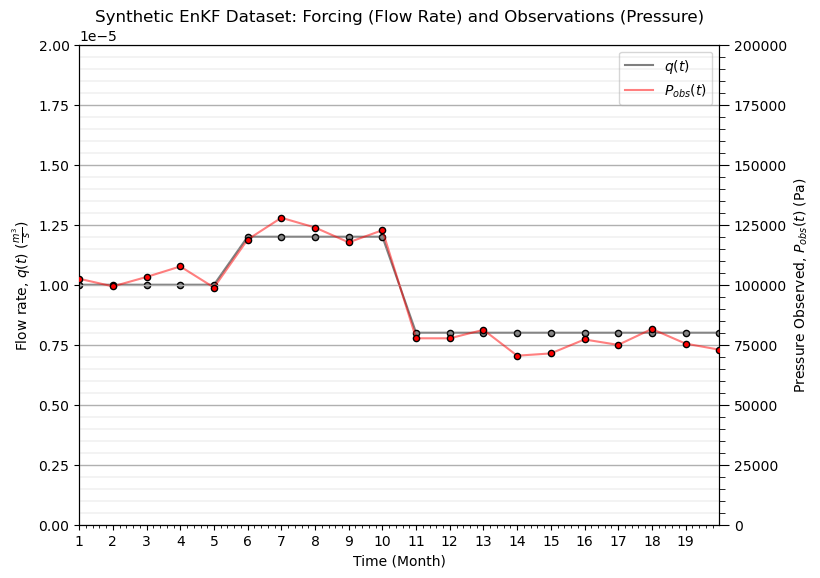

In [3]:
T = 20                                                        # number of produciton time and EnKF assimulation steps

k_true = 1.0e-13                                              # true permeability
q = np.ones(T) * 1e-5                                         # observation error variance
                    
sigma_obs = 5000.0                                            # pressure observed error in st.dev.
R = sigma_obs**2                    
                    
q = np.ones(T) * 1e-5                                         # known forcing (flow rate)
q[5:10] = 1.2e-5
q[10:] = 8e-6

data = build_synthetic_pressure_dataset(T=T,k_true=k_true,q_t=q,R=R,random_seed=42,return_true=True) # generate synthetic dataset

t = data["t"]  + 1                                            # extract time and pressure
P_obs = data["P_obs"]
P_true = data["P_true"]

fig, ax1 = plt.subplots()                                     # plot historical production data over time 
line1 = ax1.plot(t, q,color = 'black',alpha=0.5,label=r"$q(t)$",zorder=1)
ax1.set_xlabel("Time (Month)"); ax1.set_ylabel(r"Flow rate, $q(t)$ ($\frac{m^3}{s}$)"); ax1.set_ylim([0.0e-5,2.0e-5])
ax2 = ax1.twinx()
line2 = ax2.plot(t, P_obs, color="red",alpha=0.5,label=r"$P_{obs}(t)$")
ax2.set_ylabel(r"Pressure Observed, $P_{obs}(t)$ (Pa)"); ax2.set_ylim([0,200000])
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
plt.xlim([1,np.max(t)]); plt.xticks(np.arange(1, len(t), 1))
ax1.scatter(t,q,color='grey',edgecolor='black',s=20,zorder=100)
ax2.scatter(t,P_obs,color='red',edgecolor='black',s=20,zorder=100)

plt.title("Synthetic EnKF Dataset: Forcing (Flow Rate) and Observations (Pressure)"); add_grid()
plt.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.3, hspace=0.3); plt.show()

#### Assign Prior Model

Generate a prior model, an ensemble of permeability realizations,

Assuming a lognormal distribution with $\mu = log⁡(1.2 \times 10^{−13})$ and $\sigma = 0.5$.

Each member represents,

* different permeability fields 

* different porosity realizations 

* prior geological uncertainty

This is a prior uncertainty model, prior to integration of historical production data.

Note, EnFK updates entire ensemble together at each time step

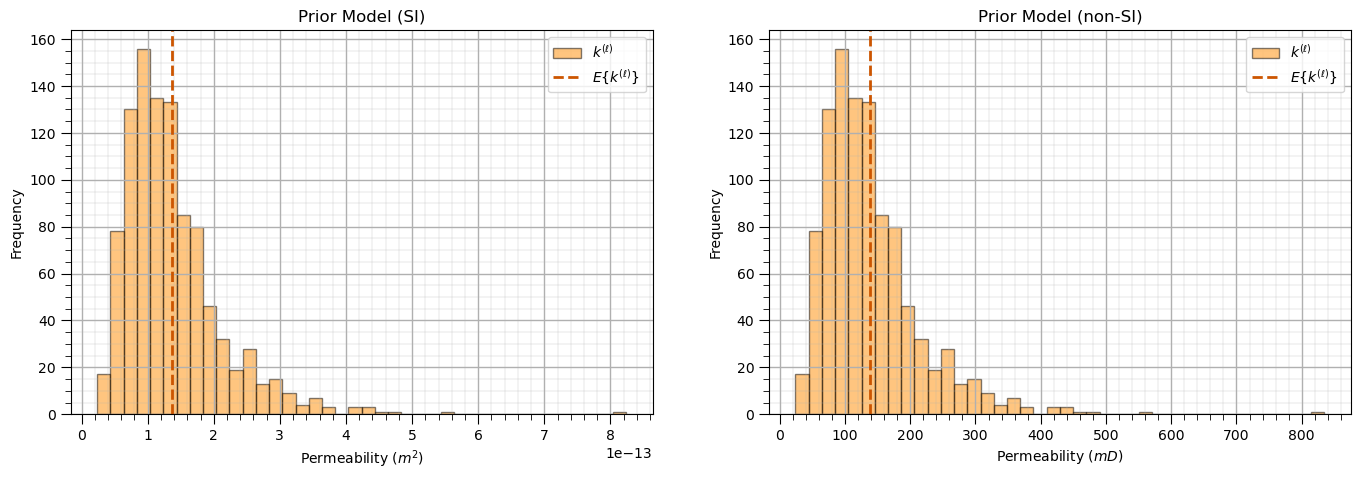

In [4]:
Ne = 1000                                                     # set number of samples in ensemble
mu = np.log(1.2e-13); sigma = 0.5

# k_prior = np.random.lognormal(mean=np.log(1.2e-13),sigma=0.5,size=Ne) # Monte Carlo simulation from prior distribution
k_prior = generate_initial_ensemble(N_e=Ne, mu_logk=mu,       # Monte Carlo simulate initial k ensemble from lognormal distribution
    sigma_logk=sigma,random_seed=seed) 
    
kmD_prior = k_prior/9.86923e-16

plt.subplot(121)                                              # plot SI permeability ensemble histogram
plt.hist(k_prior,color='darkorange',edgecolor='black',alpha=0.5,bins=40,label=r'$k^{(\ell)}$')
plt.axvline(np.mean(k_prior),color="#CC5500",linestyle='--',linewidth=2,label=r'$E\{k^{(\ell)}\}$')
add_grid(); plt.xlabel(r'Permeability ($m^2$)'); plt.ylabel('Frequency'); plt.title('Prior Model (SI)'); plt.legend(loc="upper right")

plt.subplot(122)
plt.hist(kmD_prior,color='darkorange',edgecolor='black',alpha=0.5,bins=40,label=r'$k^{(\ell)}$') # plot mD permeability ensemble histogram
plt.axvline(np.mean(kmD_prior),color="#CC5500",linestyle='--',linewidth=2,label=r'$E\{k^{(\ell)}\}$')
add_grid(); plt.xlabel(r'Permeability ($mD$)'); plt.ylabel('Frequency'); plt.title('Prior Model (non-SI)'); plt.legend(loc="upper right")

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=0.8, wspace=0.2, hspace=0.2); plt.show()

#### EnKF Assimulation Cycles Over Time Steps

We have all the parts,

* physically plausible presure observations, $P_{obs}(t)$ over time given hidden true permeability and flow rate schedule

* prior ensemble of permeability values, assigned at initial time, $t = 0$, $k^{\ell}(0)$

* functions for each step of the EnKF assimulation cycle

Below is the code for the assimulation loops over all time steps.

In [5]:
k_history = []                                                # initialize list to store all permeability ensemble values over time
k_history = [k_prior.copy()]                                  # assign time step 0 as the prior permeability ensemble

mu = 1e-3; L = 1.0; A = 1.0                                   # assign model constants as discussed above, viscosity, path length and area
alpha = 0.3                                                   # analogous to step size to slow learning

rho = 1.00                                                    # inflation / dampenning factor, slow learning for improved visualization of process                           

np.random.seed(seed=seed)                                     # set random number seed for workflow repeatability

k = k_prior                                                   # current copy of permeability essemble as the prior ensemble

for t_step in range(len(t)):                                  # ENKF LOOP over assimulation cycles for each time step
    k_f = k.copy()                                            # make a working copy of the permeability essemble

    P_hat = (q[t_step] * mu * L) / (k_f * A)                  # forward forecast at current time step
    P_obs_ens = np.full(Ne, P_obs[t_step])                    # replicate single observation Ne times for ensemble update (consistent vector length)                  
 
    k_mean = np.mean(k_f); P_mean = np.mean(P_hat)            # calculate ensemble statistics, mean, variance, then covariance and cross-covariance

    C_kP = np.sum((k_f - k_mean) * (P_hat - P_mean)) / (Ne - 1)
    C_PP = np.sum((P_hat - P_mean)**2) / (Ne - 1)

    K = C_kP / (C_PP + R)                                     # calculate Kalman gain, since 1 location we use simplified scalar form

    k_a = k_f + alpha * K * (P_obs_ens - P_hat)               # calculate updated permeability ensemble

    k_mean = np.mean(k_a)                                     # apply dampenning factor to slow assimulation for improved visualization of process
    k_a = k_mean + rho * (k_a - k_mean)

    k_a = np.clip(k_a, 1e-16, None)                           # optional physical constraint

    k = k_a                                                   # update permeability ensemble list and add to 2D array for visualization over time steps
    k_history.append(k.copy())

#### Visualize EnKF Assimulation Cycles Over Time Steps

Now let's visualize the permeability ensemble over the assimulation cycles over all time steps, including,

* permeability ensemble over time

* true (hidden) permeability

* ensemble average permeability 

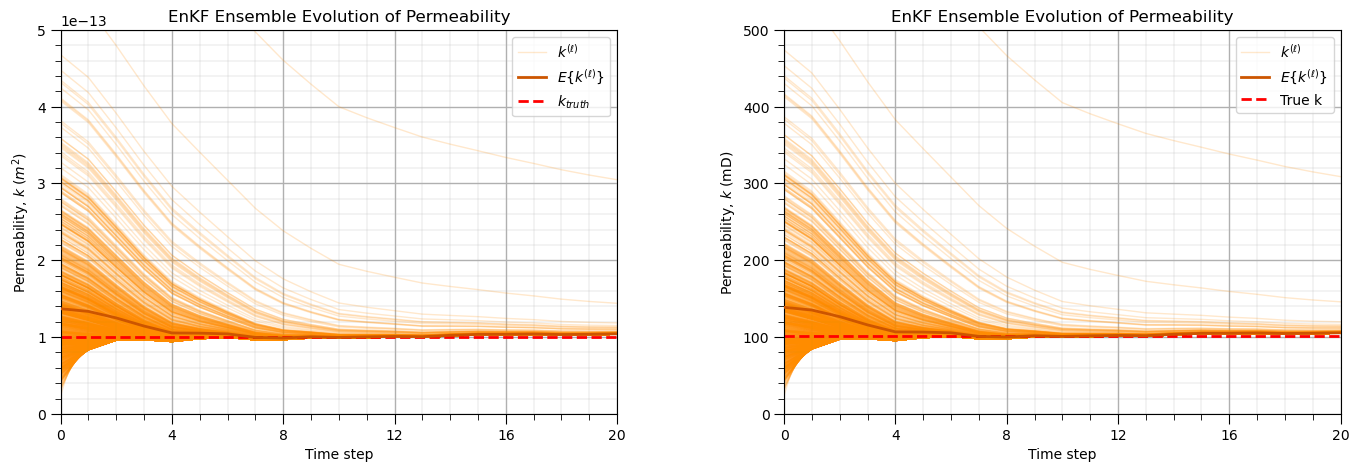

In [6]:
k_history_array = np.array(k_history)                         # convert 2D permeabilty ensemble to 2D ndarray
kmD_history_array = k_history_array/9.86923e-16               # convert to mD for improved visualizations
kmD_true = k_true/9.86923e-16

T, Ne = k_history_array.shape; time = np.arange(T)            # new time index with prior at t = 0

plt.subplot(121)                                              # plot permeability ensembles over assimulation cycles
for i in range(Ne):
    if i == 0:
        plt.plot(time, k_history_array[:, i], color="darkorange", alpha=0.2, linewidth=1,label=r'$k^{(\ell)}$')
    else:
        plt.plot(time, k_history_array[:, i], color="darkorange", alpha=0.2, linewidth=1)
k_mean = np.mean(k_history_array, axis=1)
plt.plot(time,k_mean,color="#CC5500",linewidth=2,label=r'$E\{k^{(\ell)}\}$',zorder=10)
plt.axhline(k_true, color="red", linestyle="--",linewidth=2,label=r'$k_{truth}$')
plt.xlabel("Time step"); plt.ylabel(r"Permeability, $k$ ($m^2$)"); plt.title("EnKF Ensemble Evolution of Permeability")
plt.xlim([0,20]); plt.ylim([0,0.5e-12]); plt.legend(); add_grid()
plt.xticks(np.arange(0, len(time), 4))

plt.subplot(122)
for i in range(Ne):
    if i == 0:
        plt.plot(time, kmD_history_array[:, i], color="darkorange", alpha=0.2, linewidth=1,label=r'$k^{(\ell)}$')
    else:
        plt.plot(time, kmD_history_array[:, i], color="darkorange", alpha=0.2, linewidth=1)
kmD_mean = np.mean(kmD_history_array, axis=1)
plt.plot(time, kmD_mean,color="#CC5500",linewidth=2,label=r'$E\{k^{(\ell)}\}$',zorder=10)
plt.axhline(kmD_true,color="red",linestyle="--",linewidth=2,label="True k")
plt.xlabel("Time step"); plt.ylabel(r"Permeability, $k$ (mD)"); plt.title("EnKF Ensemble Evolution of Permeability")
plt.xlim([0,20]); plt.ylim([0,500.0]); plt.legend(); add_grid()
plt.xticks(np.arange(0, len(time), 4))

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=0.8, wspace=0.3, hspace=0.3); plt.show()

These results look good. Here are some observations,

* prior permeability ensemble at ($t=0$) with high spread initialized as our log normally distributed prior with biased high mean

* assimilated permeability ensemble over assimulation cycles for every time step, $t = 1,\ldots,T$, reduces uncertainty (lower variance) and corrects mean (closer to hidden truth permeability)

* posterior permeability ensemble stabilizes with ensemble mean convergence to hidden truth permeability, uncertainty envelope narrowed but does not collapse

#### Visualize Permeability Ensemble Distributions Over Assimulation Cycles

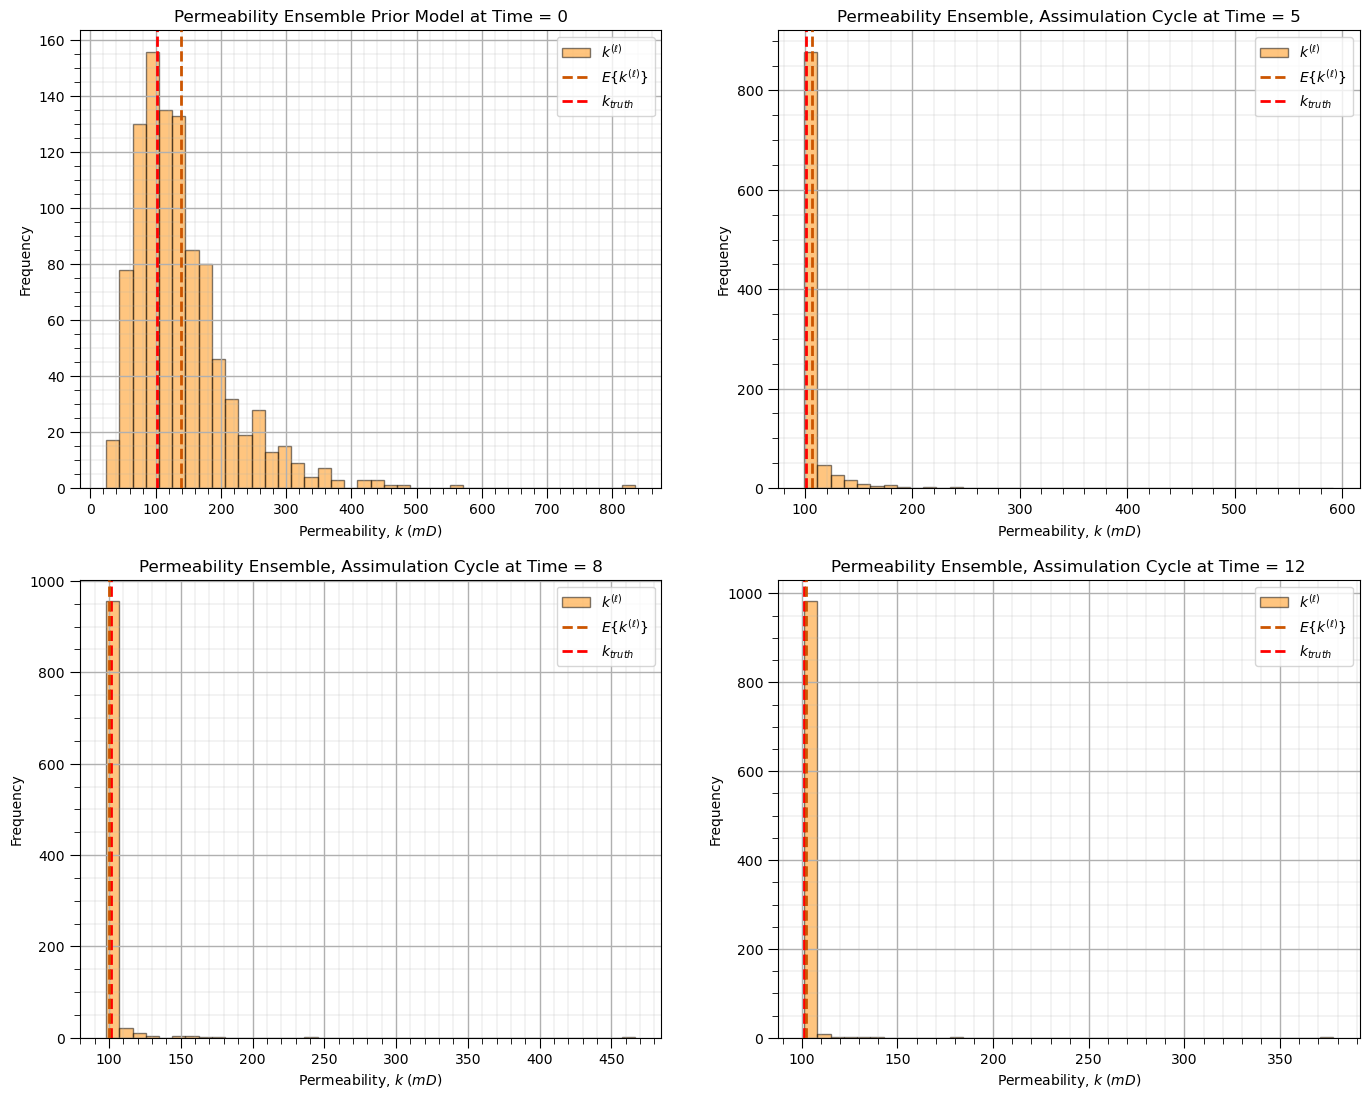

In [7]:
viz_T = [0,5,8,12]                                            # assign assimulation cycles, time steps to plots

index = 1                                                     # plot the permeability ensemble histograms at each time step
for viz_t in viz_T:
    plt.subplot(2,2,index)
    plt.hist(kmD_history_array[viz_t,:],color='darkorange',edgecolor='black',bins=40,alpha=0.5,label=r'$k^{(\ell)}$') # plot mD permeability ensemble histogram
    plt.axvline(np.mean(kmD_history_array[viz_t,:]),color="#CC5500",linestyle='--',linewidth=2,label=r'$E\{k^{(\ell)}\}$',zorder=10)
    plt.axvline(kmD_true, color='red', linestyle='--', linewidth=2,label=r'$k_{truth}$'); plt.legend(loc='upper right') 
    add_grid(); plt.xlabel(r'Permeability, $k$ ($mD$)'); plt.ylabel('Frequency')
    if viz_t == 0:
        plt.title('Permeability Ensemble Prior Model at Time = 0')
    else:
        plt.title('Permeability Ensemble, Assimulation Cycle at Time = ' + str(viz_t))        
    index = index + 1

plt.subplots_adjust(left=0.0, bottom=0.0, right=2.0, top=2.1, wspace=0.2, hspace=0.2); plt.show()

These histograms of the permeability ensemble over assimulation cycles on time steps issustrate,

* permeability ensemble mean is converging on the hidden truth permeability

* the uncertainty is descreasing and then forms a stable posterior after sufficient assimulation cycles

#### Comments

This was a basic demonstration of history matching with Ensemble Kalman Filter (EnKF).  

* In the effort to provide a maximally accessible demonstration of the workflow, I have certainty erred on the side of simplicity with a single cell model.

* Yet, I think this is a good introduction with all the steps and calculations shown. 

Much more can be done, I have other demonstrations for modeling workflows with GeostatsPy in the GitHub repository [GeostatsPy_Demos](https://github.com/GeostatsGuy/GeostatsPy_Demos/tree/main).

I hope this is helpful,

*Michael*

#### About the Author

<figure style="text-align: center;">
  <img src="_static/intro/michael_pyrcz_officeshot_jacket.jpg" style="display: block; margin: 0 auto; width: 70%;">
  <figcaption style="text-align: center;"> Professor Michael Pyrcz in his office on the 40 acres, campus of The University of Texas at Austin.
</figcaption>
</figure>

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 90 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### Want to Work Together?

I hope this content is helpful to those that want to learn more about subsurface modeling, data analytics and machine learning. Students and working professionals are welcome to participate.

* Want to invite me to visit your company for training, mentoring, project review, workflow design and / or consulting? I'd be happy to drop by and work with you! 

* Interested in partnering, supporting my graduate student research or my Subsurface Data Analytics and Machine Learning consortium (co-PI is Professor John Foster)? My research combines data analytics, stochastic modeling and machine learning theory with practice to develop novel methods and workflows to add value. We are solving challenging subsurface problems!

* I can be reached at mpyrcz@austin.utexas.edu.

I'm always happy to discuss,

*Michael*

Michael Pyrcz, Ph.D., P.Eng. Professor, Cockrell School of Engineering and The Jackson School of Geosciences, The University of Texas at Austin

More Resources Available at: [Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)